In [4]:
from arraylake import Client
import zarr

client = Client()

repo = client.get_repo("taylor-geospatial/ftw-global")

session = repo.readonly_session(branch="main")

root = zarr.open_group(
    session.store,
    zarr_format=3,
    mode="r"
)

print(root.tree())

/
├── band (3,) <U20
├── spatial_ref () int64
├── time (2,) int64
├── variables (2, 3, 1566049, 4007517) float32
├── x (4007517,) float64
└── y (1566049,) float64



In [5]:
print(root.tree())

print("Bands:")
print(root["band"][:])

print("Time:")
print(root["time"][:])

print("Variables shape:")
print(root["variables"].shape)

print("Variables dtype:")
print(root["variables"].dtype)

/
├── band (3,) <U20
├── spatial_ref () int64
├── time (2,) int64
├── variables (2, 3, 1566049, 4007517) float32
├── x (4007517,) float64
└── y (1566049,) float64

Bands:
['non_field_background' 'field' 'field_boundaries']
Time:
[  0 366]
Variables shape:
(2, 3, 1566049, 4007517)
Variables dtype:
float32


In [6]:
import numpy as np

# Read a small 256 x 256 patch
patch = root["variables"][0, :, 100000:100256, 100000:100256]

print("Patch shape:", patch.shape)
print("Patch dtype:", patch.dtype)
print("Minimum value:", patch.min())
print("Maximum value:", patch.max())

Patch shape: (3, 256, 256)
Patch dtype: float32
Minimum value: nan
Maximum value: nan


In [10]:
import numpy as np

patch = root["variables"][0, :, 100000:100256, 100000:100256]

print("Patch shape:", patch.shape)

print("NaN count:", np.isnan(patch).sum())

print("Total values:", patch.size)

print("NaN percentage:", np.isnan(patch).sum() / patch.size * 100)

print("Valid minimum:", np.nanmin(patch))

print("Valid maximum:", np.nanmax(patch))

Patch shape: (3, 256, 256)
NaN count: 196608
Total values: 196608
NaN percentage: 100.0
Valid minimum: nan
Valid maximum: nan


C:\Windows\Temp\ipykernel_91456\420976489.py:13: RuntimeWarning: All-NaN slice encountered
  print("Valid minimum:", np.nanmin(patch))
C:\Windows\Temp\ipykernel_91456\420976489.py:15: RuntimeWarning: All-NaN slice encountered
  print("Valid maximum:", np.nanmax(patch))


In [11]:
# Read a much smaller area from the beginning of the dataset
small_area = root["variables"][0, :, 0:1024, 0:1024]

print("Shape:", small_area.shape)
print("NaN percentage:", np.isnan(small_area).sum() / small_area.size * 100)
print("Valid minimum:", np.nanmin(small_area))
print("Valid maximum:", np.nanmax(small_area))

Shape: (3, 1024, 1024)
NaN percentage: 100.0


C:\Windows\Temp\ipykernel_91456\3661674476.py:6: RuntimeWarning: All-NaN slice encountered
  print("Valid minimum:", np.nanmin(small_area))
C:\Windows\Temp\ipykernel_91456\3661674476.py:7: RuntimeWarning: All-NaN slice encountered
  print("Valid maximum:", np.nanmax(small_area))


Valid minimum: nan
Valid maximum: nan


In [12]:
import numpy as np

variables = root["variables"]

# نجرب نقاط مختلفة كل 100,000 pixel
y_points = [0, 100000, 500000, 1000000, 1500000]
x_points = [0, 100000, 1000000, 2000000, 3000000, 4000000]

for y in y_points:
    for x in x_points:
        patch = variables[0, :, y:y+256, x:x+256]
        valid_percentage = np.isfinite(patch).sum() / patch.size * 100
        
        if valid_percentage > 0:
            print(
                f"Found data at y={y}, x={x}, "
                f"valid={valid_percentage:.2f}%"
            )

Found data at y=0, x=1000000, valid=87.50%
Found data at y=100000, x=1000000, valid=100.00%
Found data at y=100000, x=3000000, valid=100.00%
Found data at y=500000, x=1000000, valid=100.00%
Found data at y=500000, x=2000000, valid=100.00%
Found data at y=500000, x=3000000, valid=100.00%
Found data at y=1000000, x=4000000, valid=100.00%


Patch shape: (3, 256, 256)


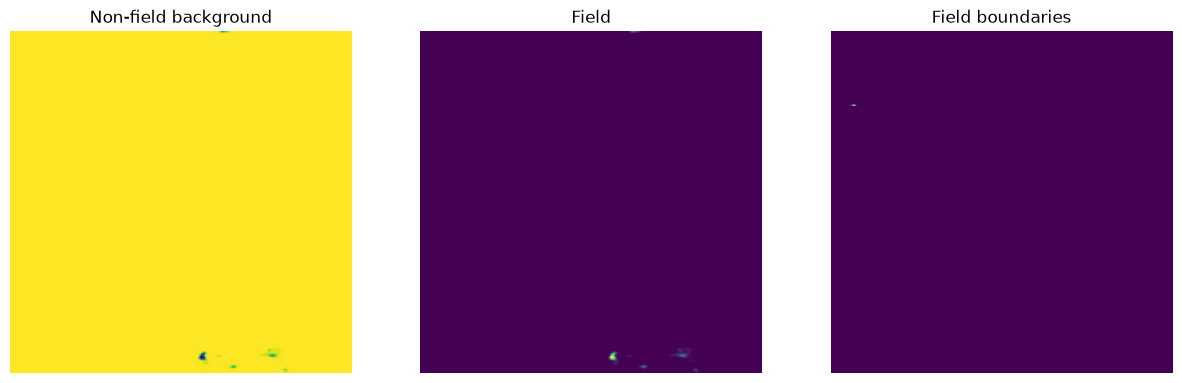

In [13]:
import matplotlib.pyplot as plt

# Choose a valid location
y_start = 100000
x_start = 1000000

# Read one time point
patch = root["variables"][0, :, y_start:y_start+256, x_start:x_start+256]

print("Patch shape:", patch.shape)

# Plot the three classes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(patch[0])
axes[0].set_title("Non-field background")
axes[0].axis("off")

axes[1].imshow(patch[1])
axes[1].set_title("Field")
axes[1].axis("off")

axes[2].imshow(patch[2])
axes[2].set_title("Field boundaries")
axes[2].axis("off")

plt.show()

In [14]:
for i, band_name in enumerate(root["band"][:]):
    values = patch[i]
    
    print(f"\n{band_name}")
    print("Minimum:", np.nanmin(values))
    print("Maximum:", np.nanmax(values))
    print("Unique values:", np.unique(values)[:20])


non_field_background
Minimum: 0.046297293
Maximum: 1.0
Unique values: [0.04629729 0.0540604  0.0770337  0.09518166 0.14123335 0.19416763
 0.21802971 0.21922787 0.23373786 0.23968808 0.24578415 0.27092034
 0.33356673 0.38691455 0.39231512 0.43607822 0.5105041  0.53748286
 0.5992001  0.60827136]

field
Minimum: 7.70249e-12
Maximum: 0.95370275
Unique values: [7.7024897e-12 7.9866374e-12 8.6385630e-12 8.9114549e-12 9.5569672e-12
 1.0080489e-11 1.1600448e-11 1.1959101e-11 1.2337312e-11 1.2519245e-11
 1.4020408e-11 1.4805790e-11 1.5953431e-11 1.5984193e-11 1.6364497e-11
 1.6499200e-11 1.7407163e-11 1.7865563e-11 1.8043433e-11 1.8394395e-11]

field_boundaries
Minimum: 1.5795858e-17
Maximum: 0.00040198368
Unique values: [1.5795858e-17 2.8380431e-17 3.3033266e-17 3.3694332e-17 3.6790026e-17
 3.7495760e-17 4.4226300e-17 4.8797826e-17 5.1818104e-17 5.6312286e-17
 5.6792858e-17 5.6939791e-17 5.7218717e-17 5.7341067e-17 5.8553945e-17
 8.0027964e-17 8.0325365e-17 8.3342351e-17 8.4024318e-17 8.91858

In [15]:
sum_probs = patch.sum(axis=0)

print("Minimum sum:", np.nanmin(sum_probs))
print("Maximum sum:", np.nanmax(sum_probs))

print("Mean sum:", np.nanmean(sum_probs))

Minimum sum: 0.9999999
Maximum sum: 1.0000001
Mean sum: 1.0


In [16]:
# Convert probability maps into class labels
label_mask = np.argmax(patch, axis=0)

print("Label mask shape:", label_mask.shape)
print("Unique labels:", np.unique(label_mask))

Label mask shape: (256, 256)
Unique labels: [0 1]


In [17]:
print("Boundary max:", patch[2].max())
print("Boundary mean:", patch[2].mean())

print("Number of pixels where boundary is highest:",
      np.sum(np.argmax(patch, axis=0) == 2))

Boundary max: 0.00040198368
Boundary mean: 1.9377696e-08
Number of pixels where boundary is highest: 0


In [18]:
variables = root["variables"]

y_points = [0, 100000, 500000, 1000000]
x_points = [1000000, 2000000, 3000000, 4000000]

for y in y_points:
    for x in x_points:
        test_patch = variables[0, :, y:y+256, x:x+256]

        if np.isnan(test_patch).all():
            continue

        labels = np.argmax(test_patch, axis=0)
        boundary_pixels = np.sum(labels == 2)

        print(
            f"y={y}, x={x}, "
            f"boundary pixels={boundary_pixels}, "
            f"boundary max={test_patch[2].max():.6f}"
        )

y=0, x=1000000, boundary pixels=0, boundary max=nan
y=100000, x=1000000, boundary pixels=0, boundary max=0.000402
y=100000, x=3000000, boundary pixels=254, boundary max=1.000000
y=500000, x=1000000, boundary pixels=73, boundary max=1.000000
y=500000, x=2000000, boundary pixels=31, boundary max=0.998118
y=500000, x=3000000, boundary pixels=0, boundary max=0.000005
y=1000000, x=4000000, boundary pixels=0, boundary max=0.000000


In [19]:
y_start = 100000
x_start = 3000000

patch = root["variables"][
    0,
    :,
    y_start:y_start+256,
    x_start:x_start+256
]

print("Patch shape:", patch.shape)

print("Background max:", np.nanmax(patch[0]))
print("Field max:", np.nanmax(patch[1]))
print("Boundary max:", np.nanmax(patch[2]))

Patch shape: (3, 256, 256)
Background max: 1.0
Field max: 1.0
Boundary max: 0.9999999


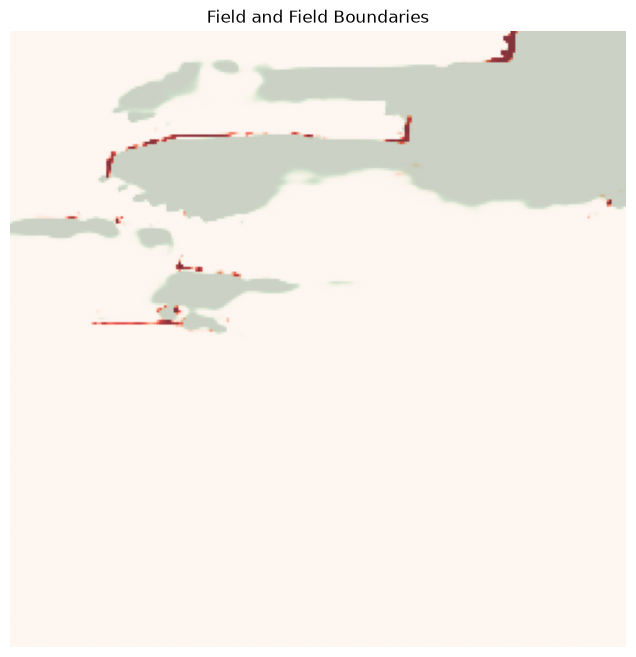

In [20]:
import matplotlib.pyplot as plt

background = patch[0]
field = patch[1]
boundary = patch[2]

plt.figure(figsize=(8, 8))

# Field probability
plt.imshow(field, cmap="Greens", vmin=0, vmax=1)

# Boundary probability فوق الـ field
plt.imshow(
    boundary,
    cmap="Reds",
    vmin=0,
    vmax=1,
    alpha=0.8
)

plt.title("Field and Field Boundaries")
plt.axis("off")

plt.show()

In [21]:
background_mask = patch[0] > 0.5
field_mask = patch[1] > 0.5
boundary_mask = patch[2] > 0.5

print("Background pixels:", background_mask.sum())
print("Field pixels:", field_mask.sum())
print("Boundary pixels:", boundary_mask.sum())

Background pixels: 54238
Field pixels: 11028
Boundary pixels: 248


In [22]:
import torch
from torch.utils.data import Dataset


class FTWDataset(Dataset):

    def __init__(self, root, time_index=0, patch_size=256):
        self.root = root
        self.variables = root["variables"]
        self.time_index = time_index
        self.patch_size = patch_size

        # Dataset dimensions
        self.height = self.variables.shape[2]
        self.width = self.variables.shape[3]

    def __len__(self):
        return 100

    def __getitem__(self, idx):

        # For now, use our known valid location
        y_start = 100000
        x_start = 3000000

        patch = self.variables[
            self.time_index,
            :,
            y_start:y_start + self.patch_size,
            x_start:x_start + self.patch_size
        ]

        # Convert Zarr data to NumPy
        patch = np.asarray(patch)

        # Convert probability maps to binary masks
        background_mask = patch[0] > 0.5
        field_mask = patch[1] > 0.5
        boundary_mask = patch[2] > 0.5

        # Create target with 3 channels
        target = np.stack([
            background_mask,
            field_mask,
            boundary_mask
        ])

        # Convert to PyTorch tensors
        target = torch.tensor(target, dtype=torch.float32)

        return target

In [23]:
dataset = FTWDataset(root)

print("Dataset length:", len(dataset))

sample = dataset[0]

print("Sample shape:", sample.shape)
print("Sample dtype:", sample.dtype)

Dataset length: 100
Sample shape: torch.Size([3, 256, 256])
Sample dtype: torch.float32


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

batch = next(iter(loader))

print("Batch shape:", batch.shape)

SyntaxError: invalid syntax (387410917.py, line 1)